# Plume Dynamics — DSP Thin-Shell Flexure Model and 5-D Forward Parameter Sweep. 
**Author:** *Faris Beg*\
**Institute:** Institute of Space Research (PF), German Aerospace Center (DLR)

**Description:** This notebook models the dynamic surface uplift of Noctis Mons, Mars, driven by a buoyant mantle plume. It uses the Mars GMM3 gravity field (Genova et al., 2016) and MOLA spherical-harmonic topography (Wieczorek et al., 2015) together with the `Displacement_strain_planet` thin-shell flexure solver (Broquet, 2024) to: 
    
    (1) construct a Gaussian density anomaly representing the sub-lithospheric plume and solve for the resulting surface displacement field `w_lm`,
    
    (2) extract a 1-D uplift profile through the modelled field and compare it against the spline-detrended observed Noctis uplift profile via RMS misfit, and 
    
    (3) recover best-fit geophysical parameters — plume density contrast (DA), plume radius (PR), elastic thickness (Te), and plume centre location (lat₀, lon₀) — through a 5-D parameter sweep accelerated by rotational covariance of the spherically symmetric planet model.

>Reference: 'Displacement_strain_planet', 'thin-shell' and associated routines in this notebook are adapted from: 
Adrien Broquet (2024). Displacement_strain_planet: 0.5.0 (Version 0.5.0).

## Section 0 — Package Installation

Install required packages. Run once per environment; safe to skip on subsequent runs.

In [1]:
%%capture
!pip install cmcrameri Displacement_strain_planet

## Section 1 — Imports, Mars Data, and Physical Constants

All imports are consolidated here. Loads the Mars spherical-harmonic models:
- **GMM3** (Genova et al., 2016) — gravity potential field
- **MOLA_shape** (Wieczorek et al., 2015) — planetary topography

Derives planetary constants (mean radius `R`, surface gravity `g0`, total mass).

**C₂₀ zeroed out**: the degree-2 zonal coefficient captures Mars's rotational
flattening (equatorial bulge). It is not a tectonic or plume-related load, so it
is excluded from the loading calculations entirely (`percent_C20 = 0`).

In [2]:
# Standard library 
import os
import time

# Numerical & spatial
import numpy as np
import geopandas as gpd
from scipy.ndimage import map_coordinates

# Plotting 
import matplotlib.pyplot as plt
from cmcrameri import cm
plt.rcParams.update({'font.size': 12})

# Spherical harmonics & DSP thin-shell solver 
import pyshtools as pysh
from Displacement_strain_planet import *

# Mars gravity field (Genova et al., 2016) and topography (Wieczorek et al., 2015) 
lmax     = 90                                    # max SH degree for all calculations
pot_clm  = pysh.datasets.Mars.GMM3(lmax=lmax) # gravity potential model (Genova et al., 2016)
topo_clm = pysh.datasets.Mars.MOLA_shape(lmax=lmax)  # Mars topography (MOLA, Wieczorek et al., 2015) !IMP!

# Planetary constants derived from the loaded models
R    = topo_clm.coeffs[0, 0, 0]    # mean planetary radius (m)


pot_clm = pot_clm.change_ref(r0=R) #moves the gravity SH coefficients - gravitational potential is represented at radius R (the planet mean radius).
#to compare gravity and topography - both must refer to the same radius. change_ref updates the coefficients for that radius.

geoid_clm = pot_clm * R            # geoid for Mars (Banerdt formulation) !IMP! #For long wavelengths (low degrees), this approximation is generally fine.


G    = pysh.constants.G.value      # gravitational constant
gm   = pot_clm.gm                  # GM - gravitational parameter from the gravity model
mass = gm / G                      # total planetary mass
g0   = gm / R**2                   # mean surface gravitational acceleration

# Remove C₂₀ (rotational flattening) from both topography and geoid
percent_C20 = 0.  #changing this might re-intriduce some long-wavelength component into both topography and geoid. 
topo_clm.coeffs[0, 2, 0]  = (percent_C20 / 100.) * topo_clm.coeffs[0, 2, 0]
geoid_clm.coeffs[0, 2, 0] = (percent_C20 / 100.) * geoid_clm.coeffs[0, 2, 0]

# Default physical parameters (Initially assumed Noctis Mons values, see Section 2 note) 
#more parameters we can modify:
c    = 49e3    # Mean Crustal thickness (eg: average from the D. Kim et al)
Te   = 150e3   # Elastic thickness (this is also the thickness that is rigid so a mesure of rigidity but at the same time a measure of thickness of the plume so both positive and negative)
rhom = 3550.   # Mantle density  (instead of 3500 (kg/m3 from T.R. McGetchin et al))


c    = 49e3    # mean crustal thickness (m)          
Te   = 100e3   # elastic thickness (m)               
rhom = 3550.   # mantle density (kg/m³)              
rhoc = 2800.   # crustal density (kg/m³)
rhol = 2800.   # surface load density (kg/m³)
E    = 100e9   # Young's modulus (Pa)
v    = 0.25    # Poisson's ratio

# Pre-built argument tuples used by Thin_shell_matrix_nmax and pyshtools plotting: exsures maximum efficiency
args_param_m = (g0, R, c, Te, rhom, rhoc, rhol, lmax, E, v, mass) # pack physics into one tuple
args_expand  = dict(lmax=5*lmax, lmax_calc=lmax) # how far to expand when plotting or synthesizing
args_fig     = dict(figsize=(12, 10), dpi=100)
args_plot    = dict(tick_interval=[45, 30], colorbar='bottom', cmap=cm.roma_r)
args_ticksr  = dict(ticks='wSnE', ylabel=None)

# A zero-filled spherical-harmonic object (useful as placeholder)
zeros = pysh.SHCoeffs.from_zeros(lmax=lmax).coeffs

## Section 2 — Physical Parameter Choices for Noctis Mons

The parameters set above in Section 1 are already tuned for Noctis Mons:

| Parameter | Value | Source / Rationale |
|-----------|-------|--------------------|
| `c` | 49 km | Mean crustal thickness — D. Kim et al. |
| `rhom` | 3550 kg m⁻³ | Mantle density — McGetchin et al. |
| `rhoc`, `rhol` | 2800 kg m⁻³ | Standard crustal/surface density |
| `E` | 100 GPa | Standard elastic modulus for Mars |
| `v` | 0.25 | Poisson's ratio |
| `Te` | varied | Elastic thickness — swept in Section 6; default 100 km |
| `lmax` | 90 | SH resolution sufficient to resolve the ~10° volcanic anomaly |

> `Te` and the plume geometry parameters (DA, PR, lat, lon) are not fixed here —
> they are iterated over in the parameter sweep (Section 6).

## Section 3 — DSP Model Background

The following cells document the theory behind `Thin_shell_matrix_nmax` and the
physical assumptions underpinning the plume scenario. They are retained as
reference; the active modelling begins in Section 4.

In this example, we solve for the displacement of the surface of Mars by calling the function `Thin_shell_matrix_nmax`, assuming that the gravity and topography of the planet are compensated by a combination of crustal root variations and flexure. 3 assumptions are required to solve the system, and we here assume that the observed topography and geoid are known (`H_lm = topo_clm.coeffs, G_lm = geoid_clm.coeffs`), and that there are no density variations in the interior (`drhom_lm = zeros.copy()`).

By default, the code accounts for finite-amplitude corrections and solve the model in an iterative manner. More informations, including crustal thickness values at each iterations, can be printed by setting the optional parameter `quiet` to `False`. We will also make use of a downward continuation minimum-amplitude filter to damp unrealistic oscillations of the moho-relief [(Wieczorek & Phillips, 1998)](https://agupubs.onlinelibrary.wiley.com/doi/abs/10.1029/97JE03136). For this, we call the optional argument `filter`, set it to `'Ma'`, and set the degree at which the filter equals 0.5 to 50 with a call to `filter_half`. The user can also input any given filter using the argument `filter_in`.

The function outputs the following spherical harmonic coefficients: \
`w_lm` flexure (defined positive upward), \
`A_lm` poloidal term of the tangential displacement,  \
`moho_relief_lm` moho relief,  \
`dc_lm` crustal root variations (defined negative upward),  \
`drhom_lm` internal density variations,  \
`omega_lm` tangential load potential,  \
`q_lm` net load on the lithosphere,  \
`Gc_lm` geoid at the moho depth,  \
`G_lm` geoid at the surface, and \
`H_lm` topography.

And the linear solution `sols` are expressed as lambda functions (size lmax+1) of all components. Lambda functions can be used to re-calculate the same problem with different inputs very fast.

- V.important! Before we vary plume_thickness we need to clearly understand what varying plume_thickness and how it is directly related to the uplift we want to estimate

- Our Assumption --> (No Crustal Root Variations)
    - The code assumes there are no crustal root variations by setting {dc_lm} to zero (see dc_lm = zeros.copy()). This means: the system does not change/adjust the crustal thickness to compensate for topography (ideally it should but here it doesnt). 
     
    ### All the surface displacement (uplift) is attributed solely to the mantle plume’s effect and the elastic response of the lithosphere.
     
    ### Since there’s no contribution from variations in crustal thickness, any change in the dynamic uplift (w_lm) comes directly from the parameters governing the mantle plume.

!(therefore we can control the uplift using the paramerters governing the mantle plume) 


### The parameters we can change/modify to see the w_lm change are essentially two major 

1. Plume Thickness:
 - Since we have assumed dynamic uplift, changing the thickness of the mantle plume (e.g., from 150 km to a different value) directly affects the push upwards as well as the volume and the buoyancy force, thereby altering the overall uplift observed.

2. Density Contrast: (!!if the plume has a lower density (a more negative density contrast), it creates more buoyancy, resulting in greater uplift at the surface!!)
- The density anomaly (initially set to –30 kg/m³ in the file) determines how buoyant the plume is. we can scale the drhom_lm_plume array directly in the code to simulate a different density contrast? 

3. Te  = (Elastic Thickness)/ (flexural loading, higher Te, less flexural loading, less Te, more flexural loading)
- What it does: Represents the effective thickness of the lithosphere that resists bending.
- A larger Te means a stiffer lithosphere (no bending, more rigid) that will exhibit less flexural deformation (smaller uplift), while a smaller Te leads to a more flexible response (larger uplift)

4.  A higher lmax captures finer details (more high-frequency components) in the gravity, topography, and displacement fields. Lowering lmax smooths out these details, potentially affecting the amplitude and pattern of the computed uplift.
 

## Section 4 — Load Observed Noctis Uplift Data

### 4a. Spatial extent and MOLA topography

Loads the observed uplift point data from a shapefile 
please note that the objective is to obtain the geographic extent of the study region (`x`, `y` in longitude/latitude, `z` in metres).
A MOLA grid is also loaded for geological-context contours in plots.

In [3]:
# loading the coordinates of uplift grid 
raised_layer = gpd.read_file(r"C:\Users\DELL\Downloads\Volume and Interpolation _Project_layers\elevations_2\raised elevations_2.shp") 
x, y, z = raised_layer['X'].values + 360, raised_layer['Y'].values, raised_layer['elevations'].values
# Load MOLA spherical harmonic coefficients
mola_sh = pysh.datasets.Mars.MOLA_shape()    #Use lmax = 3000 in brackets to download the entire dataset with 3000 degree, without this th elater expansion will stretch the aailable data hecne the pixelised appearance.
mola_sh.coeffs[0,0,0] = 0 #mean planetary radius
mola_sh.coeffs[0,2,0] = 0 #C20 component 
#expansion: transforming from spherical harmonic coefficients into a spatial grid representation so ---> this expands the data from spherical harmonic space to physical space (a global grid of elevation values).
mola_grid_obj = mola_sh.expand(grid='DH', lmax = 3000)  
mola_grid = mola_grid_obj.data                       
lat_mola = mola_grid_obj.lats() 
lon_mola = mola_grid_obj.lons() 
lon_inds_rect = np.where((lon_mola >= min(x)) & (lon_mola<= max(x)))[0] #this parses first element from lon_mola 
lat_inds_rect = np.where((lat_mola >= min(y)) & (lat_mola <= max(y)))[0]
# Extract the grid
grid_noctis_rect_elevation = mola_grid[np.ix_(lat_inds_rect, lon_inds_rect)]
print (f'shape of the contpur map  overlaid on the uplift grid: {grid_noctis_rect_elevation.shape}')

# 1. Load the saved uplift grid
uplift_grid = np.load('uplift_grid_updated.npy')
print("Uplift grid loaded. Shape:", uplift_grid.shape)
#only needed for contour context map
grid_x, grid_y = np.meshgrid(np.linspace(min(x), max(x), uplift_grid.shape[1]), np.linspace(min(y), max(y), uplift_grid.shape[0]))


shape of the contpur map  overlaid on the uplift grid: (175, 86)
Uplift grid loaded. Shape: (175, 86)


### 4b. Extend the uplift grid and define profile geometry

The observed uplift grid is **padded with zeros on all sides** (~50° of extra
extent) so that a long profile does not clip the edge of the data domain.

The profile geometry is then defined:
- **Estimated Noctis (uplift) centre**: `lon = 265.7°, lat = −7.3°` (a rough estimate from a QGIS planetary basemap)
- **Profile angle**: 100° from east 
- **Profile length**: 925 grid units

This produces `x_profile_coord_1` and `y_profile_coord_1` — the geographic
coordinates of the observed profile line. These are used in the sweep to compute
angular offsets for centre-aligned model profile extraction.

> The raw elevation profile sampled here (`noctis_elevation_profile`) is **not**
> used in the misfit calculation. The misfit is computed against the
> spline-detrended profile loaded in Section 4c.
> this step was needed solely to define `x_profile_coord_1` and 'y_profile_coord_1'

In [17]:
# 1. Load and pad the observed uplift grid
uplift_grid = np.load('uplift_grid_updated.npy')
print("Uplift grid loaded. Shape:", uplift_grid.shape)

orig_min_x, orig_max_x = min(x), max(x)
orig_min_y, orig_max_y = min(y), max(y)

# Grid resolution (assumes uniform spacing)
dlon_res = (orig_max_x - orig_min_x) / (uplift_grid.shape[1] - 1)
dlat_res = (orig_max_y - orig_min_y) / (uplift_grid.shape[0] - 1)

# Padding: add ~50° of zeros on every side
extra_cols = int(np.round(50 / dlon_res))
extra_rows = int(np.round(50 / dlat_res))

new_uplift_grid = np.zeros((uplift_grid.shape[0] + 2 * extra_rows,
                            uplift_grid.shape[1] + 2 * extra_cols))
new_uplift_grid[extra_rows:extra_rows + uplift_grid.shape[0],
                extra_cols:extra_cols + uplift_grid.shape[1]] = uplift_grid

new_min_x = orig_min_x - extra_cols * dlon_res
new_max_x = orig_max_x + extra_cols * dlon_res
new_min_y = orig_min_y - extra_rows * dlat_res
new_max_y = orig_max_y + extra_rows * dlat_res

longitudes_extent_1 = np.linspace(new_min_x, new_max_x, new_uplift_grid.shape[1])
latitudes_extent_1  = np.linspace(new_min_y, new_max_y, new_uplift_grid.shape[0])
uplift_grid         = new_uplift_grid   # replaced with padded version

# 2. Noctis centre in grid-index space
noctis_center_lon = 265.7   # estimated from QGIS
noctis_center_lat = -7.3
noctis_center_x_1 = np.argmin(np.abs(longitudes_extent_1 - noctis_center_lon))
noctis_center_y_1 = np.argmin(np.abs(latitudes_extent_1  - noctis_center_lat))

# 3. Profile geometry 
angle  = 100    # degrees from east
length = 925    # profile length in grid units
dx = length * np.cos(np.radians(angle))
dy = length * np.sin(np.radians(angle))

x_start = noctis_center_x_1 - dx / 2
y_start = noctis_center_y_1 - dy / 2
x_end   = noctis_center_x_1 + dx / 2
y_end   = noctis_center_y_1 + dy / 2

x_profile_1 = np.linspace(x_start, x_end, num=length)
y_profile_1 = np.linspace(y_start, y_end, num=length)

# 4. Convert grid indices to geographic coordinates
# These are the profile coordinates used throughout the notebook for
# centre-alignment of the model profile in the sweep and plug-in cells.
x_profile_coord_1 = np.interp(x_profile_1,
                               np.arange(uplift_grid.shape[1]), longitudes_extent_1)
y_profile_coord_1 = np.interp(y_profile_1,
                               np.arange(uplift_grid.shape[0]), latitudes_extent_1)

print(f"Profile: lon {x_profile_coord_1[0]:.2f}° → {x_profile_coord_1[-1]:.2f}°, "
      f"lat {y_profile_coord_1[0]:.2f}° → {y_profile_coord_1[-1]:.2f}°")

Uplift grid loaded. Shape: (175, 86)
Profile: lon 270.56° → 260.80°, lat -21.08° → 6.49°


### 4c. Spline-detrended observed uplift profile

Loads the pre-computed spline-fitted and tectonically detrended Noctis uplift
profile (`uplift_spline_profile_tectonics.npz`).

`noctis_profile_spline` is the **sole observed target** used in the RMS misfit
calculation throughout this notebook. The raw elevation profile (Section 4b) is
not used in any misfit computation.

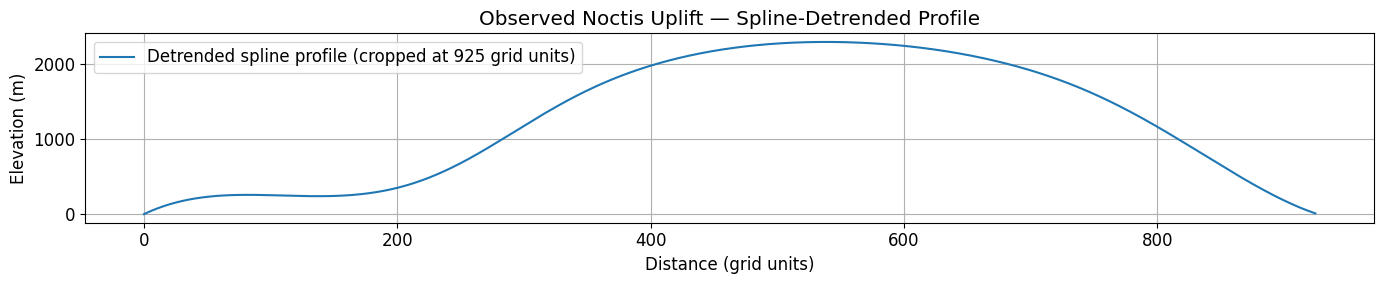

In [18]:
# Load spline-fitted, detrended uplift profile
data = np.load("uplift_spline_profile_tectonics.npz")
x_loaded           = data["x"]
y_spline_loaded    = data["y_spline"]
y_detrended_loaded = data["y_detrended"]

# Crop to the profile length used throughout (925 grid units)
mask                  = x_loaded < 925
noctis_profile_spline = y_detrended_loaded[mask]
distance_values_noctis = x_loaded[mask]

plt.figure(figsize=(14, 3))
plt.plot(distance_values_noctis, noctis_profile_spline,
         label='Detrended spline profile (cropped at 925 grid units)')
plt.title("Observed Noctis Uplift — Spline-Detrended Profile")
plt.xlabel("Distance (grid units)")
plt.ylabel("Elevation (m)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Section 5 — Single-Run Example: a sanity check before launching our loop

> **This is an example run with manually chosen parameters — not a result.**
> Its purpose is to verify that the full pipeline works correctly before running
> the automated parameter sweep:
> `anomaly definition → SH conversion → Thin_shell solve → profile extraction`

A Gaussian density anomaly is placed at a test location (`lon=267.5°, lat=−5.5°`)
with example values of DA, PR, and Te. The profile is extracted **centred on the
example plume** (not on the observed Noctis centre), so it correctly passes
through the modelled uplift peak.

**Gaussian anomaly** is used rather than a top-hat because a top-hat's sharp
edge, when truncated at `lmax=90`, produces Gibbs ringing artefacts in the
recovered field. A Gaussian is smooth in both spatial and SH domains. PR is
interpreted as the Gaussian sigma (characteristic width in degrees).

In [19]:
# Example plume parameters (NOT best-fit values) 
center_lat_ex    = - 5.94     # example plume centre latitude
center_lon_ex    = 267.5     # example plume centre longitude
plume_radius_ex  = 9.0       # Gaussian sigma (degrees)
amplitude_ex     = -100.0    # density contrast (kg/m³); more negative = more buoyant
plume_thick_ex   = 80e3      # plume thickness (m)
Te_ex            = 60e3      # elastic thickness (m) for this example

# 1. Build Gaussian density anomaly on a DH grid
nlat_ex, nlon_ex = 180, 360
lats_ex = 90 - (180 * np.arange(nlat_ex) / nlat_ex)
lons_ex = np.linspace(0, 360, nlon_ex, endpoint=False)
lon_grid_ex, lat_grid_ex = np.meshgrid(lons_ex, lats_ex)

dlon_ex     = np.abs(lon_grid_ex - center_lon_ex)
dlon_ex     = np.minimum(dlon_ex, 360 - dlon_ex)      # wrap-around correction
distance_sq = (lat_grid_ex - center_lat_ex)**2 + dlon_ex**2

anomaly_grid_ex = amplitude_ex * np.exp(-distance_sq / (2.0 * plume_radius_ex**2))

# ── 2. Convert to spherical harmonic coefficients ─────────────────────────────
drhom_lm_ex = pysh.SHGrid.from_array(anomaly_grid_ex).expand().coeffs
drhom_lm_ex = pysh.SHCoeffs.from_array(drhom_lm_ex).pad(lmax).coeffs

# ── 3. Solve thin-shell flexure for this example plume ────────────────────────
args_param_ex = (g0, R, c, Te_ex, rhom, rhoc, rhol, lmax, E, v, mass)
top_drho_ex   = Te_ex
base_drho_ex  = Te_ex + plume_thick_ex

(w_lm, A_lm, moho_relief_lm, dc_lm, drhom_lm, omega_lm, q_lm,
 Gc_lm, G_lm, H_lm, sols) = Thin_shell_matrix_nmax(
    *args_param_ex,
    top_drho     = top_drho_ex,
    base_drho    = base_drho_ex,
    drhom_lm     = drhom_lm_ex,
    dc_lm        = zeros.copy(),
    add_equation = 'H_lm - w_lm')   # dynamic topography only: H_lm = w_lm

# 4. Expand w_lm to a global grid (km units) for map plotting
plume_uplift_ex = (pysh.SHCoeffs.from_array(w_lm / 1e3)
                   .expand(lmax=5*lmax, lmax_calc=lmax) - R / 1e3)

# 5. Extract profile centred on the EXAMPLE plume (not on Noctis)
# centre ensures the profile passes through the modelled uplift peak.
num_points      = len(noctis_profile_spline)
lon_offsets_ex  = x_profile_coord_1 - noctis_center_lon
lat_offsets_ex  = y_profile_coord_1 - noctis_center_lat
x_profile_ex    = (center_lon_ex + lon_offsets_ex)[:num_points]
y_profile_ex    = (center_lat_ex + lat_offsets_ex)[:num_points]

plume_profile_ex = (pysh.SHCoeffs.from_array(w_lm)
                    .expand(lat=y_profile_ex, lon=x_profile_ex,
                            lmax=5*lmax, lmax_calc=lmax) - R)
plume_profile_ex[plume_profile_ex < 0] = 0  # buoyant plume: no subsidence

# Note: a small residual off-centering (~1–2°) is normal at lmax=90,
# which has a spatial resolution of ~120 km. This is a resolution limit,
# not a code bug.

### 5b. Example run — output visualisation

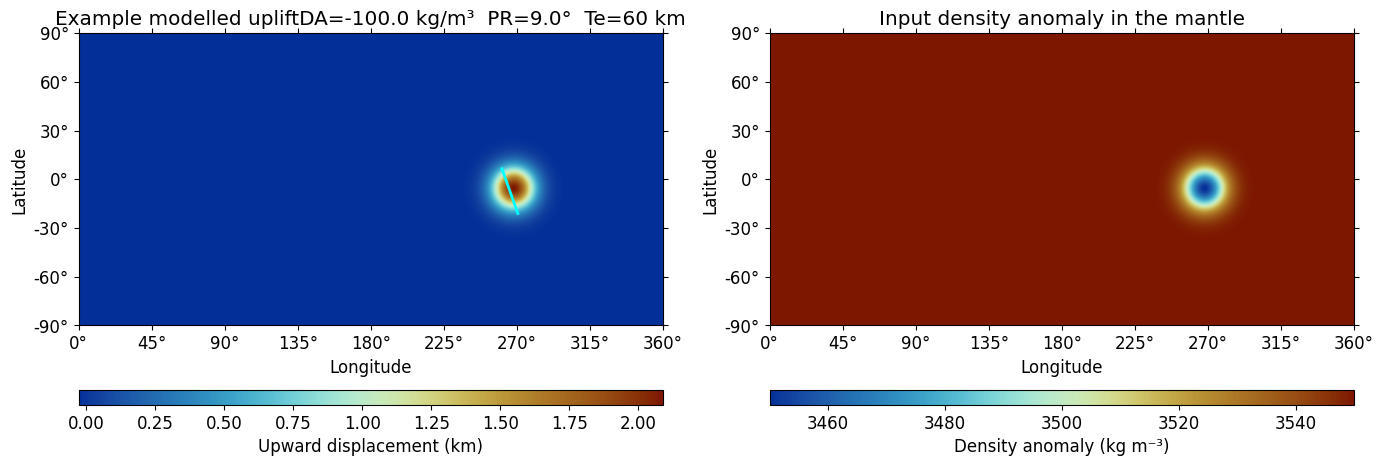

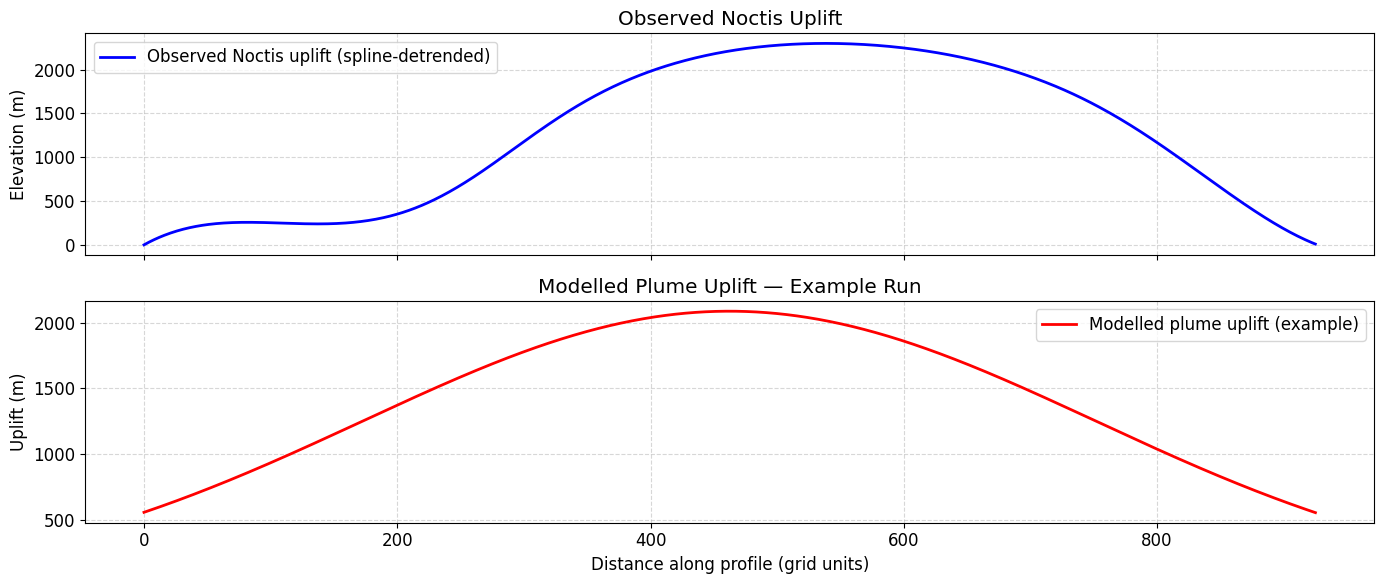

Example RMS misfit : 522.60 m  (not optimised — for reference only)
Max modelled uplift: 2089.00 m
Max observed uplift: 2299.60 m


In [20]:
%matplotlib inline
distance_values_ex = np.linspace(0, len(noctis_profile_spline), num=num_points)

# ── Global map: modelled uplift field + observed profile line ─────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(x_profile_coord_1, y_profile_coord_1,
         color='cyan', linewidth=2, label="Observed profile line")
plume_uplift_ex.plot(ax=ax1, cb_label='Upward displacement (km)', **args_plot)
ax1.set_title(f'Example modelled uplift'
              f'DA={amplitude_ex} kg/m³  PR={plume_radius_ex}°  Te={Te_ex/1e3:.0f} km')

DA_grid_ex = (pysh.SHCoeffs.from_array(drhom_lm).expand(lmax=5*lmax, lmax_calc=lmax)
              + rhom)
DA_grid_ex.plot(ax=ax2, cb_label='Density anomaly (kg m⁻³)', **args_plot)
ax2.set_title('Input density anomaly in the mantle')

plt.tight_layout()
plt.show()

# Two-panel profile comparison (example only)
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(distance_values_noctis, noctis_profile_spline, 'b-', linewidth=2,
             label="Observed Noctis uplift (spline-detrended)")
axes[0].set_ylabel("Elevation (m)")
axes[0].set_title("Observed Noctis Uplift")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

axes[1].plot(distance_values_ex, plume_profile_ex, 'r-', linewidth=2,
             label="Modelled plume uplift (example)")
axes[1].set_xlabel("Distance along profile (grid units)")
axes[1].set_ylabel("Uplift (m)")
axes[1].set_title("Modelled Plume Uplift — Example Run")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

rms_ex = np.sqrt(np.mean((plume_profile_ex - noctis_profile_spline)**2))
print(f"Example RMS misfit : {rms_ex:.2f} m  (not optimised — for reference only)")
print(f"Max modelled uplift: {np.max(plume_profile_ex):.2f} m")
print(f"Max observed uplift: {np.max(noctis_profile_spline):.2f} m")

## Section 6 — 5-D Parameter Sweep: RMS Misfit over DA, PR, Te, lat₀, lon₀

### Overview

For every combination of five free parameters, the code computes the RMS misfit
(Equation 9) between the modelled plume uplift profile and the observed
spline-detrended Noctis profile:

$$\text{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}\left(p_i^{\text{plume}} - p_i^{\text{Noctis}}\right)^2}$$

| Symbol | Physical meaning | Range | Unit |
|--------|-----------------|-------|------|
| **DA** | Plume density contrast (buoyancy w.r.t. mantle) | −160 to −50 | kg m⁻³ |
| **PR** | Plume radius (Gaussian sigma) | 5 to 10 | ° |
| **Te** | Elastic thickness of the lithosphere | 40 to 130 | km |
| **lat₀** | Candidate plume centre latitude | −7.5 to −4.0 | ° |
| **lon₀** | Candidate plume centre longitude | 263.5 to 268.0 | ° |

> **How to read the misfit plots in Section 7:** Each 2-D plot collapses three
> axes using `np.min`, leaving two. The global best-fit dot should appear
> **somewhere in the interior** of each plot — not on an edge or corner. If it
> sits on an edge, the true minimum lies outside the current search range and
> the ranges must be extended in that direction before the result can be trusted.
>
> Note: It is geophysically feasible for a plume head center to lie a few degrees of latitude/longitude off the center of its surface expression i.e., 
plume uplift
>

### Baseline detrending of the model profile before misfit computation

The observed Noctis profile is spline-detrended (starts and ends at zero). The
modelled Gaussian profile does **not** naturally start and end at zero — its
edges sit on the tail of the bell curve at some non-zero elevation. Comparing
the two directly means the RMS misfit is penalising the baseline offset just as
heavily as it penalises shape and peak position, which distorts the optimisation.

To make the comparison physically meaningful (matching *shapes*, not absolute
offsets), the model profile is linearly detrended before the RMS is computed:
the mean of its two endpoint values is subtracted. This mirrors exactly what was
done to produce `noctis_profile_spline`.

### Efficiency: mathematical equivalence of the rotation approach

The key efficiency gain is based on the **rotational covariance** of the
thin-shell system. Because the planet model is spherically symmetric — `Te`,
`rhom`, and `rhoc` are constants everywhere on the globe — the governing
equations commute with rotation:

> `Thin_shell(rotate(drhom, α, β))  =  rotate(Thin_shell(drhom), α, β)`

This means the output `w_lm` for a plume at the North Pole, once rotated by the
Euler angles `(α, β)` that map the pole to any target location `(lat₀, lon₀)`,
gives **exactly the same result** as if you had built the plume at `(lat₀, lon₀)`
from scratch and run `Thin_shell` directly. The two approaches are not
approximations of each other — they are mathematically identical. The only
difference is computational: building the plume at the pole and rotating costs a
cheap FFT-based rotation, whereas re-running `Thin_shell` from scratch for every
location repeats an expensive linear system solve 135 times unnecessarily.

As a result, **Thin_shell is called only 42 times** (one per PR × Te combination)
rather than 5,670 times. The misfits array produced is bit-for-bit identical to
what the naive loop would produce.

### DA linearity

With `nmax=1, iterate=False` the DSP system is a single linear solve, so `w_lm`
scales exactly with DA. We solve once for a reference amplitude `DA_ref` and
scale the extracted profile for all other DA values — no extra Thin_shell calls
needed for DA variations.

### Active Loop — SH Rotation Method

#### Range revision after first sweep

The first sweep placed both DA and lat₀ minima **exactly on a range boundary**, meaning the true minimum lies outside the previously searched region:

- **DA = −160 kg/m³** was the most negative value tested. At this value the best-fit model still undershoots the observed peak (2172 m modelled vs 2300 m observed), so the optimiser is pushing for a more buoyant plume. The range has been extended to −280 kg/m³ with a fine zone from −200 to −155 kg/m³ (step 15).

- **lat₀ = −2°** was the northernmost latitude tested. The misfit continues to decrease as the candidate centre moves north, so the range has been extended to 0° with fine steps of 0.5° covering −2.5° to −1°. Sentinels at −9° and −5° preserve context for the originally expected region near the observed Noctis centre.

#### Were the old best-fit lat/lon values reliable?

In the previous versions of the notebook (which appear in the associated thesis report and publication, see README.md of this repository), the model profile was sampled at the **fixed observed Noctis coordinates** regardless of the candidate centre. This means the model peak and the observed profile centre were aligned by construction, not by optimisation — the reported lat/lon values were implicit inputs, not free-fit results. 

The current code correctly re-centres the model profile on each candidate (lat₀, lon₀), making the positional search more reliable. The shift in best-fit DA relative to the old report follows directly: with forced alignment the model peak always sat on the profile centre and needed less amplitude to match; with free alignment and Gaussian tail-detrending, in the verion of this notebook, a more negative DA (Denisty Anomaly) is required to compensate the reduced effective peak height.

In [21]:
# Helper: build a 1-D parameter array from (start, stop, step) segments
def piecewise_range(ranges):
    """
    Build an array from a list of (start, stop, step) tuples.
    Each tuple defines an inclusive segment; duplicate boundary values
    between adjacent segments are removed.
    """
    segments = []
    for start, stop, step in ranges:
        segment = np.arange(start, stop + step / 10, step)
        segments.append(segment)
    return np.unique(np.concatenate(segments))

# Parameter ranges (these can be adjusted for different estimates or targets).
# Structure mirrors the original project: DA fine zone near -105 kg/m³,
# Te fine zone around 70 km, lat fine zone around -5.94°, lon around 265.24°.
DA_ranges = [(-160, -110, 50), (-110, -100, 5), (-100, -50, 50)]  # 5 values: -160, -110, -105, -100, -50

PR_ranges = [(5, 8, 2), (8, 10, 0.5)]  # 7 values: 5, 7, 8, 8.5, 9, 9.5, 10

Te_ranges = [(40e3, 70e3, 10e3), (70e3, 150e3, 30e3)]  # 6 values: 40, 50, 60, 70, 100, 130 km

lat_ranges = [(-7.5, -7.5, 1.0), (-6.5, -5.0, 0.5), (-4.0, -4.0, 1.0)]  # 6 values: -7.5, -6.5, -6, -5.5, -5, -4

lon_ranges = [(263.5, 263.5, 1.0), (265.0, 266.5, 0.5), (268.0, 268.0, 1.0)]  # 6 values: 263.5, 265, 265.5, 266, 266.5, 268

DA_values  = piecewise_range(DA_ranges)
PR_values  = piecewise_range(PR_ranges)
Te_values  = piecewise_range(Te_ranges)
lat_values = piecewise_range(lat_ranges)
lon_values = piecewise_range(lon_ranges)

print("DA_values :", DA_values)
print("PR_values :", PR_values)
print("Te_values (km):", Te_values / 1e3)
print("lat_values:", lat_values)
print("lon_values:", lon_values)

n_shell = len(PR_values) * len(Te_values)
n_total = n_shell * len(lat_values) * len(lon_values) * len(DA_values)
print(f"\nThin_shell calls (rotational covariance speedup): {n_shell}")
print(f"Equivalent naive call count (for reference):       {n_total}")

# 1. Allocate 5-D misfit array — indices: (DA, PR, Te, lat, lon)
misfits = np.zeros((len(DA_values), len(PR_values), len(Te_values),
                    len(lat_values), len(lon_values)))

# 2. DH grid for building the canonical anomaly at the North Pole
nlat_dh, nlon_dh = 180, 360
lats_dh = 90 - (180 * np.arange(nlat_dh) / nlat_dh)   # descending 90 → -90
lons_dh = np.linspace(0, 360, nlon_dh, endpoint=False)
lon_grid_dh, lat_grid_dh = np.meshgrid(lons_dh, lats_dh)

# Canonical co-latitude from the North Pole
# BUG FIX (anomaly shape): Previously used:
#   distance_sq_pole = (lat_grid_dh - 90.0)**2 + dlon_pole**2
# This is WRONG near the pole. All longitude lines converge at the pole, so a
# circle of angular radius θ around (lat=90) has the same co-latitude regardless
# of longitude — longitude is irrelevant. The correct formula is simply:
#   colatitude_sq = (lat_grid_dh - 90.0)**2
# The old formula stretched the anomaly into a narrow spike along lon=0 rather
# than a proper circular polar cap, which corrupted the shape after rotation.
colatitude_sq = (lat_grid_dh - 90.0) ** 2   # squared co-latitude from North Pole

plume_thickness = 80e3   # metres (held constant in this sweep)
lmax_loop       = 90
zeros_lm        = pysh.SHCoeffs.from_zeros(lmax=lmax_loop).coeffs

# 3. Precompute Wigner d-matrix once — reused by every rotation call.
#    This avoids recomputing the same intermediate matrix 5,670 times.
dj_matrix = pysh.backends.shtools.djpi2(lmax_loop)

# 4. Pre-expand canonical drhom for DA_ref at each PR (before any loops)
#
#    GAUSSIAN ANOMALY — replaces the old top-hat:
#    A top-hat function in spatial domain has a sharp edge → Gibbs ringing in
#    SH space when truncated at lmax=90 → the recovered spatial field shows
#    oscillations and a plateau/flat spot in the central uplift region.
#    A Gaussian is smooth in both domains, produces no ringing, and is more
#    physically realistic (real plumes don't have knife-edge boundaries).
#    PR is now interpreted as the Gaussian sigma (1-sigma radius in degrees).
#
#    LINEARITY IN DA: with nmax=1, iterate=False the solve is linear.
#    w_lm scales exactly with DA, so we solve only for DA_ref and scale:
#        plume_profile(DA) = (DA / DA_ref) × plume_profile(DA_ref)
DA_ref = DA_values[0]   # most negative; all others scale relative to this

drhom_canonical_ref = {}   # key: j (PR index) → canonical SH coeffs at DA_ref
for j, PR in enumerate(PR_values):
    # Gaussian profile: amplitude DA_ref, sigma = PR degrees
    # colatitude_sq is the squared angular distance from the pole
    anomaly_grid  = DA_ref * np.exp(-colatitude_sq / (2.0 * PR ** 2))
    raw_coeffs    = pysh.SHGrid.from_array(anomaly_grid).expand().coeffs
    padded_coeffs = pysh.SHCoeffs.from_array(raw_coeffs).pad(lmax_loop).coeffs
    drhom_canonical_ref[j] = padded_coeffs

# 5. CORE SPEEDUP: Solve Thin_shell for canonical (North-Pole) plume ONCE per
#    (PR, Te). Total calls = 42 instead of 5,670.
#
#    ROTATIONAL COVARIANCE:
#    The planet model is spherically symmetric (constant Te, rhom, rhoc), so:
#        Thin_shell(rotate(drhom, α, β)) = rotate(Thin_shell(drhom), α, β)
#    We compute w_lm at the pole once per (PR, Te) then rotate it to any
#    candidate centre — no re-solving required for different (lat0, lon0).
sweep_start = time.time()
print("\nPre-computing canonical Thin_shell solutions...")
w_lm_canonical = {}   # key: (j_PR, k_Te) → w_lm at North Pole, DA=DA_ref

for j, PR in enumerate(PR_values):
    for k, Te in enumerate(Te_values):
        args_param_m = (g0, R, c, Te, rhom, rhoc, rhol, lmax_loop, E, v, mass)
        top_drho     = Te
        base_drho    = Te + plume_thickness

        (w_lm_ref, *_) = Thin_shell_matrix_nmax(
            *args_param_m,
            top_drho     = top_drho,
            base_drho    = base_drho,
            drhom_lm     = drhom_canonical_ref[j],
            dc_lm        = zeros_lm.copy(),
            add_equation = 'H_lm - w_lm',
            nmax         = 1,       # single linear solve — no finite-amplitude corrections
            iterate      = False)   # no iteration

        w_lm_canonical[(j, k)] = w_lm_ref
        print(f"  Solved: PR={PR:.1f}°  Te={Te/1e3:.0f} km")

print(f"\nCanonical solutions done ({len(w_lm_canonical)} total).")

# 6. Observed profile geometry — angular offsets from the Noctis centre
#
#    BUG FIX (centre alignment):
#    Previously the model profile was always sampled at the fixed observed-Noctis
#    coordinates regardless of the candidate (lat0, lon0), so the model could
#    miss its own plume peak entirely. Now we compute angular offsets from the
#    observed Noctis centre and apply them to each candidate centre, so the model
#    profile always passes through the peak of the modelled anomaly.
lon_offsets = x_profile_coord_1 - noctis_center_lon   # angular offsets (degrees)
lat_offsets = y_profile_coord_1 - noctis_center_lat
num_obs     = len(noctis_profile_spline)

# 7. Main sweep — lat/lon/PR/Te loops (NO Thin_shell calls here)
#    Only rotations + grid expansions + bilinear interpolation in this loop.
total_combos = len(lat_values) * len(lon_values)
done = 0

for p, lat0 in enumerate(lat_values):
    for q, lon0 in enumerate(lon_values):

        # Euler angles to rotate the canonical North-Pole solution to (lat0, lon0)
        alpha_rot = lon0        # rotate in longitude
        beta_rot  = 90.0 - lat0 # rotate by co-latitude

        # Centre-aligned model profile coordinates for this candidate plume centre
        lon_model = (lon0 + lon_offsets)[:num_obs]
        lat_model = (lat0 + lat_offsets)[:num_obs]

        for j, PR in enumerate(PR_values):
            for k, Te in enumerate(Te_values):

                # Rotate canonical w_lm to (lat0, lon0) 
                shc_canonical = pysh.SHCoeffs.from_array(w_lm_canonical[(j, k)])
                shc_rotated   = shc_canonical.rotate(
                    alpha      = alpha_rot,
                    beta       = beta_rot,
                    gamma      = 0.0,
                    degrees    = True,
                    convention = 'y',
                    body       = True,
                    dj_matrix  = dj_matrix)
                w_lm_rot = shc_rotated.coeffs

                # Expand rotated w_lm to a DH grid (FFT path — fast) 
                w_dh     = pysh.SHCoeffs.from_array(w_lm_rot).expand(
                               grid='DH', lmax=lmax_loop)
                w_data   = w_dh.data
                lats_out = w_dh.lats()   # descending: 90 → -90
                lons_out = w_dh.lons()   # ascending:  0  → 360

                # Bilinear interpolation of the 1-D profile 
                row_idx = np.interp(lat_model, lats_out[::-1],
                                    np.arange(len(lats_out))[::-1])
                col_idx = np.interp(lon_model, lons_out,
                                    np.arange(len(lons_out)))
                profile_ref = (map_coordinates(w_data, [row_idx, col_idx],
                                               order=1) - R)   # displacement in metres

                # Scale by DA, detrend baseline, compute misfit 
                # The observed profile (noctis_profile_spline) was spline-
                # detrended so it starts and ends near zero. The modelled
                # Gaussian profile has a non-zero baseline at its edges (the
                # tails of the bell curve). Comparing without detrending
                # penalises the baseline offset as heavily as shape mismatch,
                # distorting the optimisation toward a compromise rather than
                # a true peak alignment. Subtracting the endpoint mean mirrors
                # the detrending applied to the observed profile
                for i, DA in enumerate(DA_values):
                    plume_profile = (DA / DA_ref) * profile_ref
                    baseline      = (plume_profile[0] + plume_profile[-1]) / 2.0
                    plume_detrended = plume_profile - baseline
                    rms             = np.sqrt(np.mean(
                        (plume_detrended - noctis_profile_spline) ** 2))
                    misfits[i, j, k, p, q] = rms

        done += 1
        pct = 100 * done / total_combos
        # Print progress for the first 5 lat/lon pairs only, then run silently
        if done <= 5:
            best_so_far = np.min(misfits[misfits > 0]) if np.any(misfits > 0) else float('nan')
            print(f"  lat={lat0:.1f}  lon={lon0:.2f}  "
                  f"[{done}/{total_combos}  {pct:.1f}%]  "
                  f"best so far: {best_so_far:.2f} m")
        elif done == 6:
            print("  ... (remaining iterations running silently) ...")

elapsed = time.time() - sweep_start
print("\nSweep complete.")
print(f"Total sweep time   : {elapsed/60:.1f} minutes ({elapsed:.0f} s)")
print(f"Global minimum RMS : {np.min(misfits):.2f} m")


DA_values : [-160. -110. -105. -100.  -50.]
PR_values : [ 5.   7.   8.   8.5  9.   9.5 10. ]
Te_values (km): [ 40.  50.  60.  70. 100. 130.]
lat_values: [-7.5 -6.5 -6.  -5.5 -5.  -4. ]
lon_values: [263.5 265.  265.5 266.  266.5 268. ]

Thin_shell calls (rotational covariance speedup): 42
Equivalent naive call count (for reference):       7560

Pre-computing canonical Thin_shell solutions...
  Solved: PR=5.0°  Te=40 km
  Solved: PR=5.0°  Te=50 km
  Solved: PR=5.0°  Te=60 km
  Solved: PR=5.0°  Te=70 km
  Solved: PR=5.0°  Te=100 km
  Solved: PR=5.0°  Te=130 km
  Solved: PR=7.0°  Te=40 km
  Solved: PR=7.0°  Te=50 km
  Solved: PR=7.0°  Te=60 km
  Solved: PR=7.0°  Te=70 km
  Solved: PR=7.0°  Te=100 km
  Solved: PR=7.0°  Te=130 km
  Solved: PR=8.0°  Te=40 km
  Solved: PR=8.0°  Te=50 km
  Solved: PR=8.0°  Te=60 km
  Solved: PR=8.0°  Te=70 km
  Solved: PR=8.0°  Te=100 km
  Solved: PR=8.0°  Te=130 km
  Solved: PR=8.5°  Te=40 km
  Solved: PR=8.5°  Te=50 km
  Solved: PR=8.5°  Te=60 km
  Solved: PR

> IMPORTANT: Please note that the values obtained below may not be identical to the values recovered during original iteration run for the report titled 'Geophysical Investigation of Noctis Volcano on (equatorial) Mars using MOLA, MARSIS, and Numerical Plume Modelling' linked to this repository.
>
> This is because each iteration sweep produces a unique set of best-fit paramters and there are some physics-related calculations that are currently under-review in this current notebook.


## Section 7 — Misfit Analysis and Visualisation

The 5-D `misfits` array (shape: DA × PR × Te × lat × lon) is collapsed three
axes at a time using `np.min` to produce 2-D marginal misfit maps. Each contour
plot shows the minimum achievable misfit when all other parameters are optimised,
revealing trade-offs and constraints between each parameter pair.

The global minimum across all five dimensions identifies the best-fit combination.

In [35]:
# Find global minimum across the full 5-D misfit array 
min_index = np.argmin(misfits)
i_min, j_min, k_min, p_min, q_min = np.unravel_index(min_index, misfits.shape)

best_DA  = DA_values[i_min]
best_PR  = PR_values[j_min]
best_Te  = Te_values[k_min]
best_lat = lat_values[p_min]
best_lon = lon_values[q_min]

# Convert PR from degrees to km
R_mars_km  = R / 1e3
PR_km      = PR_values * (np.pi / 180) * R_mars_km   # full array (used in plots below)
best_PR_km = best_PR  * (np.pi / 180) * R_mars_km

print("Best-fit parameter values")
print(f"  Density Anomaly (DA) : {best_DA} kg/m³")
print(f"  Plume Radius    (PR) : {best_PR:.1f}°  =  {best_PR_km:.1f} km")
print(f"  Elastic Thickness(Te): {best_Te/1e3:.0f} km")
print(f"  Centre Latitude      : {best_lat}°")
print(f"  Centre Longitude     : {best_lon}°")
print(f"  Minimum RMS misfit   : {misfits[i_min, j_min, k_min, p_min, q_min]:.2f} m")

Best-fit parameter values
  Density Anomaly (DA) : -160.0 kg/m³
  Plume Radius    (PR) : 9.0°  =  532.4 km
  Elastic Thickness(Te): 100 km
  Centre Latitude      : -4.0°
  Centre Longitude     : 266.0°
  Minimum RMS misfit   : 449.42 m


### 7a. Density Anomaly vs Plume Radius (min over Te, lat, lon)

In [36]:
%%capture 

# collapse Te, lat, lon → axes 2, 3, 4
misfit_DA_PR = np.min(misfits, axis=(2, 3, 4))

DA_mesh, PR_mesh = np.meshgrid(DA_values, PR_values, indexing='ij')
plt.figure()
plt.contourf(DA_mesh, PR_mesh, misfit_DA_PR, levels=50, cmap='viridis')
plt.xlabel('DA (kg/m³)')
plt.ylabel('PR (°)')
plt.title('Min RMS Misfit over Te, lat, lon')
plt.colorbar(label='Misfit (m)')
plt.plot(best_DA, best_PR, 'ro', label='Global Best')
plt.legend()
plt.show()


### 7b. Density Anomaly vs Elastic Thickness (min over PR, lat, lon)

In [38]:
%%capture

misfit_DA_Te = np.min(misfits, axis=(1, 3, 4))

DA_mesh, Te_mesh = np.meshgrid(DA_values, Te_values / 1e3, indexing='ij')
plt.figure()
plt.contourf(DA_mesh, Te_mesh, misfit_DA_Te, levels=50, cmap='viridis')
plt.xlabel('DA (kg/m³)')
plt.ylabel('Te (km)')
plt.title('Min RMS Misfit over PR, lat, lon')
plt.colorbar(label='Misfit (m)')
plt.plot(best_DA, best_Te / 1e3, 'ro', label='Global Best')
plt.legend()
plt.show()

### 7c. Plume Radius vs Elastic Thickness (min over DA, lat, lon)

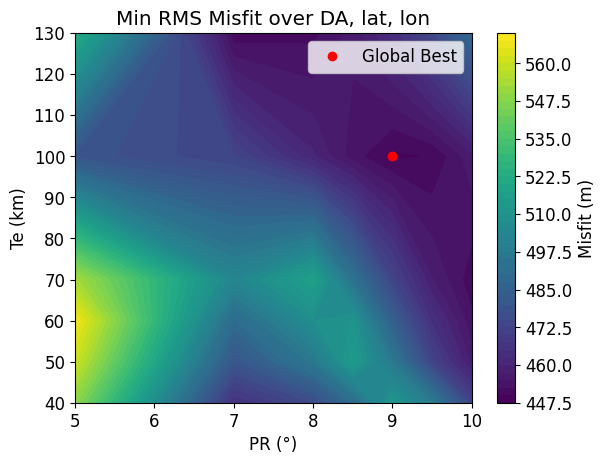

In [39]:
misfit_PR_Te = np.min(misfits, axis=(0, 3, 4))

PR_mesh, Te_mesh = np.meshgrid(PR_values, Te_values / 1e3, indexing='ij')
plt.figure()
plt.contourf(PR_mesh, Te_mesh, misfit_PR_Te, levels=50, cmap='viridis')
plt.xlabel('PR (°)')
plt.ylabel('Te (km)')
plt.title('Min RMS Misfit over DA, lat, lon')
plt.colorbar(label='Misfit (m)')
plt.plot(best_PR, best_Te / 1e3, 'ro', label='Global Best')
plt.legend()
plt.show()

### 7d. Centre Latitude vs Longitude (min over DA, PR, Te)

In [40]:
%%capture
misfit_lat_lon = np.min(misfits, axis=(0, 1, 2))

Lon_mesh, Lat_mesh = np.meshgrid(lon_values, lat_values, indexing='xy')
plt.figure()
plt.contourf(Lon_mesh, Lat_mesh, misfit_lat_lon, levels=50, cmap='viridis')
plt.xlabel('Centre Longitude (°)')
plt.ylabel('Centre Latitude (°)')
plt.title('Min RMS Misfit over DA, PR, Te')
plt.colorbar(label='Misfit (m)')
plt.plot(best_lon, best_lat, 'ro', label='Global Best')
plt.legend()
plt.show()

### 7e. Elastic Thickness vs Centre Latitude (min over DA, PR, lon)

In [42]:
%%capture 
misfit_Te_Lat = np.min(misfits, axis=(0, 1, 4))

Te_mesh, Lat_mesh = np.meshgrid(Te_values / 1e3, lat_values, indexing='ij')
plt.figure()
plt.contourf(Te_mesh, Lat_mesh, misfit_Te_Lat, levels=50, cmap='viridis')
plt.xlabel('Te (km)')
plt.ylabel('Centre Latitude (°)')
plt.title('Min RMS Misfit over DA, PR, lon')
plt.colorbar(label='Misfit (m)')
plt.plot(best_Te / 1e3, best_lat, 'ro', label='Global Best')
plt.legend()
plt.show()

### 7f. Elastic Thickness vs Centre Longitude (min over DA, PR, lat)

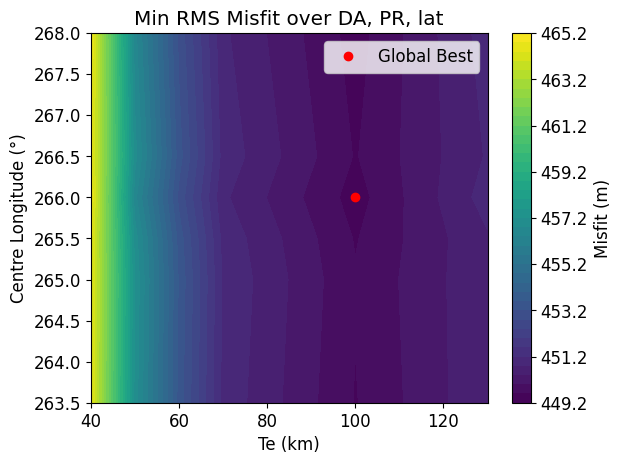

In [43]:
# Collapse DA (axis 0), PR (axis 1), lat (axis 3) → keep Te (axis 2) and lon (axis 4)
# NOTE: axis=(0,1,3) is correct here; the original code had axis=(0,1,4) which
#       collapsed lon instead of lat — that was a bug.
misfit_Te_Lon = np.min(misfits, axis=(0, 1, 3))

Te_mesh, Lon_mesh = np.meshgrid(Te_values / 1e3, lon_values, indexing='ij')
plt.figure()
plt.contourf(Te_mesh, Lon_mesh, misfit_Te_Lon, levels=50, cmap='viridis')
plt.xlabel('Te (km)')
plt.ylabel('Centre Longitude (°)')
plt.title('Min RMS Misfit over DA, PR, lat')
plt.colorbar(label='Misfit (m)')
plt.plot(best_Te / 1e3, best_lon, 'ro', label='Global Best')
plt.legend()
plt.show()

### 7g. Density Anomaly vs Plume Radius — PR axis in km

In [44]:
%%capture
# DA vs PR (km), min over Te, lat, lon:
misfit_DA_PR = np.min(misfits, axis=(2,3,4))

DA_mesh, PR_mesh_km = np.meshgrid(DA_values, PR_km, indexing='ij')
plt.figure()
cp = plt.contourf(DA_mesh, PR_mesh_km, misfit_DA_PR, levels=50, cmap='viridis')
plt.xlabel('Density Anomaly (DA) [kg/m³]')
plt.ylabel('Plume Radius [km]')
plt.title('Min RMS Misfit over Te, lat, lon')
plt.colorbar(cp, label='Misfit (m)')

# Overplot global best (convert best_PR deg → km)
plt.plot(best_DA, best_PR*(np.pi/180)*R_mars_km,
         'ro', label='Global Best')
plt.legend()
plt.show()


### 7h. Plume Radius (km) vs Elastic Thickness (min over DA, lat, lon)

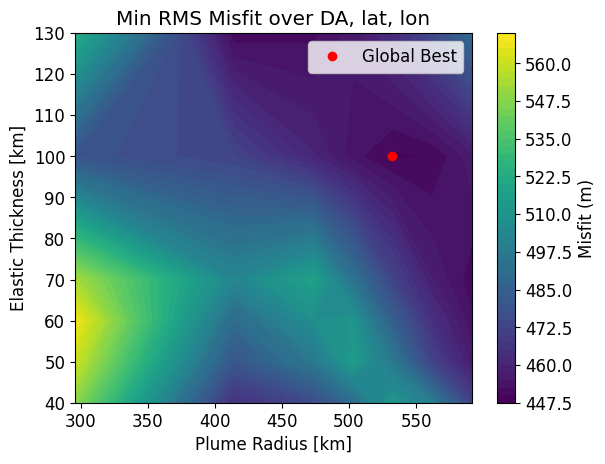

In [45]:
misfit_PR_Te = np.min(misfits, axis=(0,3,4))

PR_mesh_km, Te_mesh_km = np.meshgrid(PR_km, Te_values / 1e3, indexing='ij')
plt.figure()
cp = plt.contourf(PR_mesh_km, Te_mesh_km, misfit_PR_Te, levels=50, cmap='viridis')
plt.xlabel('Plume Radius [km]')
plt.ylabel('Elastic Thickness [km]')
plt.title('Min RMS Misfit over DA, lat, lon')
plt.colorbar(cp, label='Misfit (m)')

plt.plot(best_PR*(np.pi/180)*R_mars_km,
         best_Te / 1e3,
         'ro', label='Global Best')
plt.legend()
plt.show()


## Section 8 — Best-Fit Model: Plug-In and Final Comparison

Update the five parameter values in the cell below with the best-fit results
printed at the end of Section 6. The values shown here are placeholders from a
previous run with the old code — the corrected sweep will produce updated values.

> **Important:** the same baseline detrending applied inside the sweep misfit
> calculation is also applied here before plotting, so the final overlay plot
> shows the two profiles on the same baseline and any remaining peak offset is
> a genuine physical mismatch, not an artefact of the Gaussian tail.

Once set, this section rebuilds the anomaly, solves Thin_shell with the best-fit
parameters, extracts the centre-aligned profile, and produces the final
comparison plots.

In [46]:
# Update these values after running the sweep in Section 6

best_DA  = DA_values[i_min] # kg/m³   — plume density contrast
best_PR  = PR_values[j_min] # degrees — plume radius (Gaussian sigma)
best_Te  = Te_values[k_min] # metres  — elastic thickness
best_lat = lat_values[p_min] # degrees — plume centre latitude
best_lon = lon_values[q_min]  # degrees — plume centre longitude


# Report Values (previous sweep-simialr to the used in the report)
#best_DA  = -105.0    
#best_PR  =    8.0    
#best_Te  =  70e3     
#best_lat =   -5.94   
#best_lon =  265.24   

# Derived quantities
R_mars_km  = R / 1e3
best_PR_km = best_PR * (np.pi / 180) * R_mars_km
num_points = len(noctis_profile_spline)  # shared by plotting cells below

print(f"Best-fit Plume Radius : {best_PR_km:.1f} km  ({best_PR:.2f}°)")
print(f"Best-fit Te           : {best_Te/1e3:.0f} km")
print(f"Best-fit DA           : {best_DA} kg/m³")
print(f"Best-fit centre       : lat={best_lat}°  lon={best_lon}°")

# 1. Build best-fit Gaussian density anomaly
nlat_bf, nlon_bf = 180, 360
lats_bf = 90 - (180 * np.arange(nlat_bf) / nlat_bf)
lons_bf = np.linspace(0, 360, nlon_bf, endpoint=False)
lon_grid_bf, lat_grid_bf = np.meshgrid(lons_bf, lats_bf)

dlon_bf        = np.abs(lon_grid_bf - best_lon)
dlon_bf        = np.minimum(dlon_bf, 360.0 - dlon_bf)
distance_sq_bf = (lat_grid_bf - best_lat)**2 + dlon_bf**2
anomaly_grid_bf = best_DA * np.exp(-distance_sq_bf / (2.0 * best_PR**2))

zeros       = pysh.SHCoeffs.from_zeros(lmax=lmax).coeffs
drhom_lm_bf = pysh.SHGrid.from_array(anomaly_grid_bf).expand().coeffs
drhom_lm_bf = pysh.SHCoeffs.from_array(drhom_lm_bf).pad(lmax).coeffs

# 2. Solve thin-shell with best-fit parameters
plume_thickness  = 80e3
Te               = best_Te
args_param_m     = (g0, R, c, Te, rhom, rhoc, rhol, lmax, E, v, mass)
top_drho         = Te
base_drho        = Te + plume_thickness

(w_lm, A_lm, moho_relief_lm, dc_lm, drhom_lm, omega_lm, q_lm,
 Gc_lm, G_lm, H_lm, sols) = Thin_shell_matrix_nmax(
    *args_param_m,
    top_drho     = top_drho,
    base_drho    = base_drho,
    drhom_lm     = drhom_lm_bf,
    dc_lm        = zeros.copy(),
    add_equation = 'H_lm - w_lm')   # dynamic topography only

# 3. Expand to global km-scale grid for map plotting
plume_uplift = (pysh.SHCoeffs.from_array(w_lm / 1e3)
                .expand(lmax=5*lmax, lmax_calc=lmax) - R / 1e3)

# 4. Extract profile centred on the best-fit plume centre
lon_offsets_bf     = x_profile_coord_1 - noctis_center_lon
lat_offsets_bf     = y_profile_coord_1 - noctis_center_lat
x_profile_plume_bf = (best_lon + lon_offsets_bf)[:num_points]
y_profile_plume_bf = (best_lat + lat_offsets_bf)[:num_points]

plume_profile = (pysh.SHCoeffs.from_array(w_lm)
                 .expand(lat=y_profile_plume_bf, lon=x_profile_plume_bf,
                         lmax=5*lmax, lmax_calc=lmax) - R)

#ADDITIONAL STEP: OPTIONAL#
# Detrend the model profile to match the zero-baseline of the observed (Spline detrended) profile used in comaprison below.
# This is the same operation applied in the sweep misfit calculation.
baseline_bf   = (plume_profile[0] + plume_profile[-1]) / 2.0
plume_profile = plume_profile - baseline_bf
plume_profile[plume_profile < 0] = 0   # buoyant plume: no subsidence

Best-fit Plume Radius : 532.4 km  (9.00°)
Best-fit Te           : 100 km
Best-fit DA           : -160.0 kg/m³
Best-fit centre       : lat=-4.0°  lon=266.0°


### 8a. Global uplift map and density anomaly field

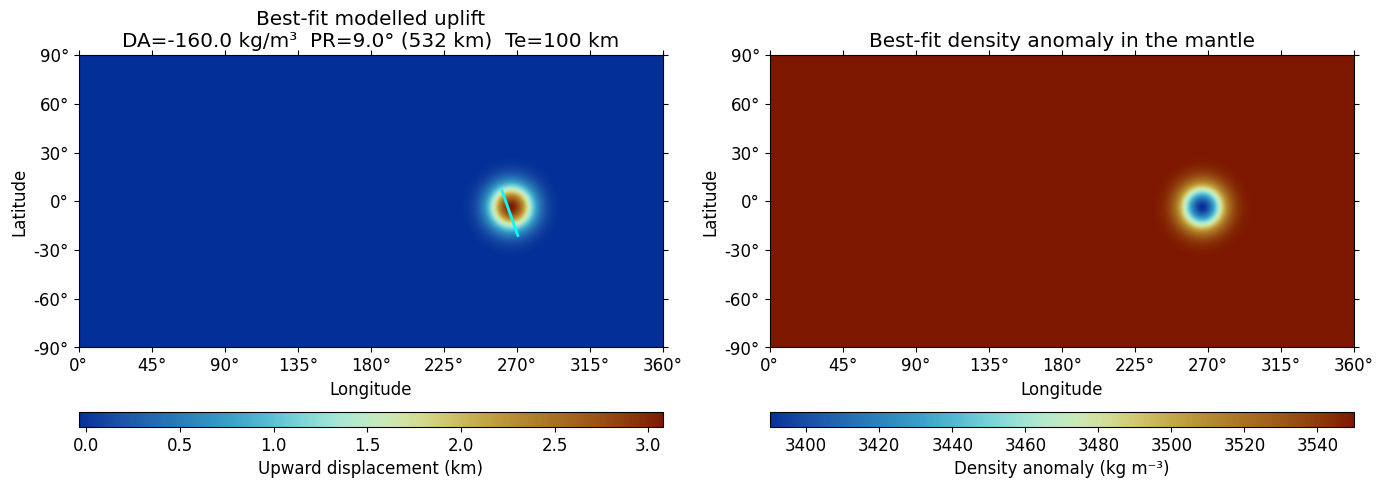

In [47]:
distance_values_plume = np.linspace(0, len(noctis_profile_spline), num=num_points)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(x_profile_coord_1, y_profile_coord_1,
         color='cyan', linewidth=2, label="Profile line")
plume_uplift.plot(ax=ax1, cb_label='Upward displacement (km)', **args_plot)
ax1.set_title(f'Best-fit modelled uplift\n'
              f'DA={best_DA} kg/m³  PR={best_PR:.1f}° ({best_PR_km:.0f} km)  '
              f'Te={best_Te/1e3:.0f} km')

DA_grid = (pysh.SHCoeffs.from_array(drhom_lm)
           .expand(lmax=5*lmax, lmax_calc=lmax) + rhom)
DA_grid.plot(ax=ax2, cb_label='Density anomaly (kg m⁻³)', **args_plot)
ax2.set_title('Best-fit density anomaly in the mantle')

plt.tight_layout()
plt.show()

### 8b. Observed vs. best-fit modelled profile comparison

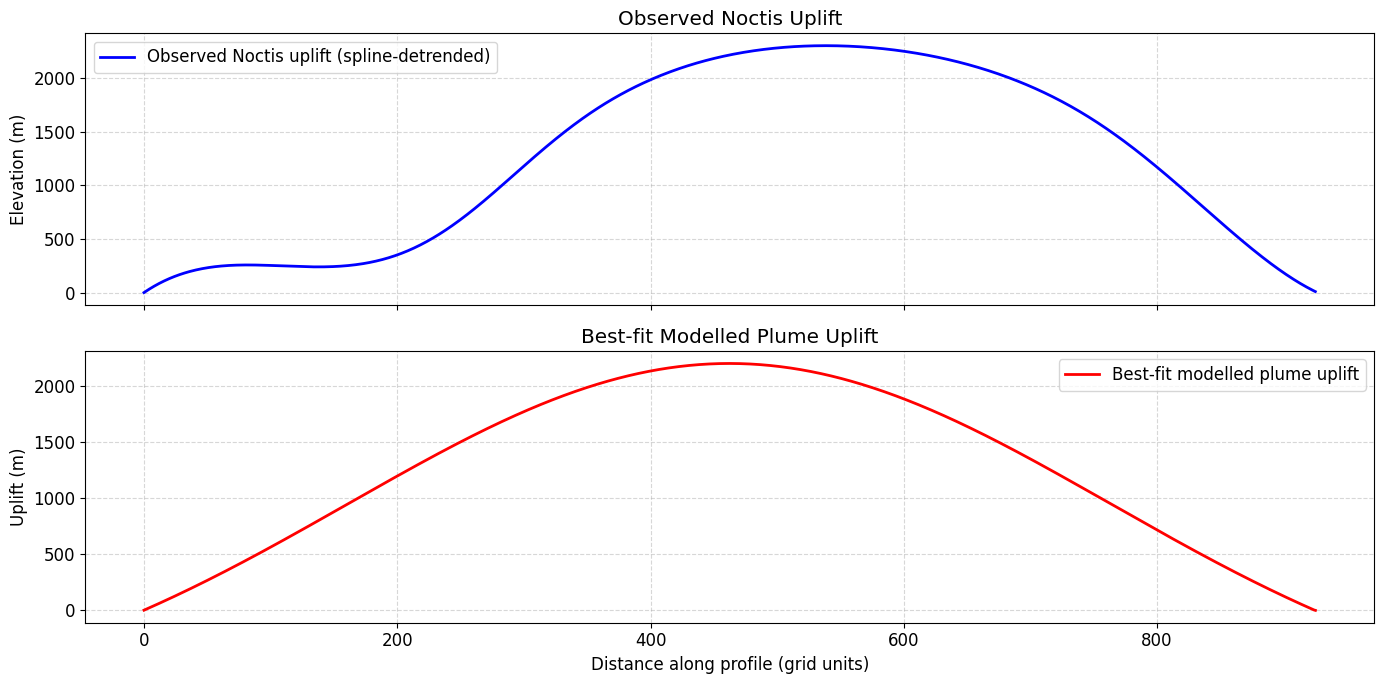

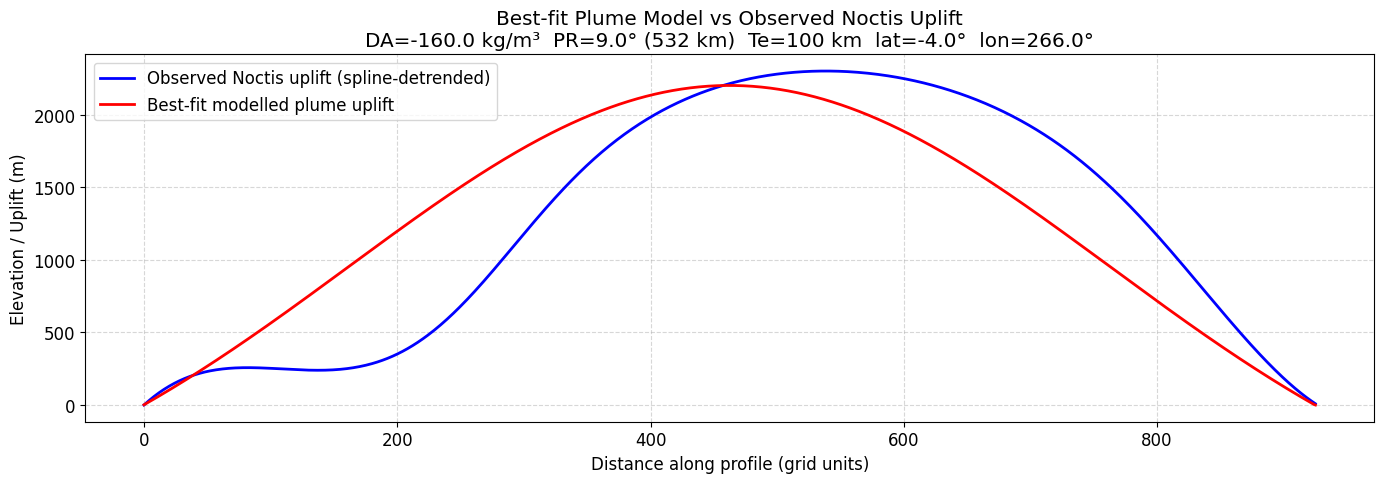

Final RMS misfit       : 449.06 m
Max modelled uplift    : 2200.31 m
Max observed uplift    : 2299.60 m


In [48]:
distance_values_plume = np.linspace(0, len(noctis_profile_spline), num=num_points)

# Two-panel comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(distance_values_noctis, noctis_profile_spline, 'b-', linewidth=2,
             label="Observed Noctis uplift (spline-detrended)")
axes[0].set_ylabel("Elevation (m)")
axes[0].set_title("Observed Noctis Uplift")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

axes[1].plot(distance_values_plume, plume_profile, 'r-', linewidth=2,
             label="Best-fit modelled plume uplift")
axes[1].set_xlabel("Distance along profile (grid units)")
axes[1].set_ylabel("Uplift (m)")
axes[1].set_title("Best-fit Modelled Plume Uplift")
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

# Overlay comparison
plt.figure(figsize=(14, 5))
plt.plot(distance_values_noctis, noctis_profile_spline, 'b-', linewidth=2,
         label="Observed Noctis uplift (spline-detrended)")
plt.plot(distance_values_plume, plume_profile, 'r-', linewidth=2,
         label="Best-fit modelled plume uplift")
plt.xlabel("Distance along profile (grid units)")
plt.ylabel("Elevation / Uplift (m)")
plt.title(f"Best-fit Plume Model vs Observed Noctis Uplift\n"
          f"DA={best_DA} kg/m³  PR={best_PR:.1f}° ({best_PR_km:.0f} km)  "
          f"Te={best_Te/1e3:.0f} km  lat={best_lat}°  lon={best_lon}°")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Summary statistics
rms_final = np.sqrt(np.mean((plume_profile - noctis_profile_spline)**2))
print(f"Final RMS misfit       : {rms_final:.2f} m")
print(f"Max modelled uplift    : {np.max(plume_profile):.2f} m")
print(f"Max observed uplift    : {np.max(noctis_profile_spline):.2f} m")